## Importação de Dependências e Configurações

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option('display.max_columns', None)

## Análise inicial dos arquivos

In [2]:
df_vendas = pd.read_csv('data\\projeto_02_ecommerce_vendas.csv')
df_vendedor = pd.read_csv('data\\projeto_02_vendedores_perfil.csv')
df_aval_sus = pd.read_csv('data\\projeto_02_avaliacoes_suspeitas.csv')


In [3]:
print('Informações Iniciais dos DataFrames -- Vendas')
print('--'*100)
print(df_vendas.info(), end='\n\n\n')
display(df_vendas.sample(5))
print('--'*100)

Informações Iniciais dos DataFrames -- Vendas
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pedido_id       8000 non-null   str    
 1   data_pedido     8000 non-null   str    
 2   hora_pedido     8000 non-null   str    
 3   vendedor_id     8000 non-null   str    
 4   categoria       8000 non-null   str    
 5   produto_id      8000 non-null   str    
 6   preco_unitario  8000 non-null   float64
 7   quantidade      8000 non-null   int64  
 8   valor_total     8000 non-null   float64
 9   frete           7767 non-null   float64
 10  estado_cliente  8000 non-null   str    
 11  status_pedido   8000 non-null   str    
 12  nota_avaliacao  5023 n

,pedido_id,data_pedido,hora_pedido,vendedor_id,categoria,produto_id,preco_unitario,quantidade,valor_total,frete,estado_cliente,status_pedido,nota_avaliacao
7188,PED-007189,2024-11-10,16:30,VEND-0074,Eletrônicos,PROD-0399,194.26,1,194.26,8.77,PA,Entregue,4.0
752,PED-000753,2024-04-10,15:09,VEND-0091,Esporte & Lazer,PROD-0230,219.15,1,219.15,36.67,CE,Entregue,5.0
3944,PED-003945,2024-03-11,23:22,VEND-0089,Casa & Decoração,PROD-0489,212.38,1,212.38,44.66,MG,Em trânsito,NaN
6425,PED-006426,2024-03-10,11:26,VEND-0089,Moda Feminina,PROD-0111,147.29,3,441.87,25.23,PR,Entregue,5.0
7574,PED-007575,2023-02-23,12:01,VEND-0091,Moda Feminina,PROD-0338,151.04,1,151.04,19.63,RN,Devolvido,NaN


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [4]:
print('Informações Iniciais dos DataFrames -- Vendedores')
print('--'*100)
print(df_vendedor.info(), end='\n\n\n')
df_vendedor.sample(5)

Informações Iniciais dos DataFrames -- Vendedores
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   vendedor_id          120 non-null    str    
 1   nome_loja            120 non-null    str    
 2   data_cadastro        120 non-null    str    
 3   cidade               120 non-null    str    
 4   estado               120 non-null    str    
 5   categoria_principal  120 non-null    str    
 6   total_vendas         120 non-null    int64  
 7   nota_media_loja      120 non-null    float64
 8   reclamacoes          120 non-null    int64  
 9   verificado           120 non-null    bool   
dtypes: bool(1), float64(1), int64(2), str(6)
memory us

,vendedor_id,nome_loja,data_cadastro,cidade,estado,categoria_principal,total_vendas,nota_media_loja,reclamacoes,verificado
100,VEND-0101,Loja IEHZC,2022-07-15,Recife,BA,Moda Feminina,646,3.5,30,False
118,VEND-0119,Loja QBJBI,2021-10-12,Manaus,MG,Casa & Decoração,1042,3.9,0,False
68,VEND-0069,Loja JQZVP,2021-07-04,Rio de Janeiro,PE,Moda Feminina,624,3.4,19,False
14,VEND-0015,Loja XKIKW,2022-07-24,Brasília,SP,Acessórios,1286,3.4,7,True
42,VEND-0043,Loja XYZ04,2023-03-11,Fortaleza,CE,Casa & Decoração,1104,4.8,2,False


In [5]:
print('Informações Iniciais dos DataFrames -- Avaliações suspeitas')
print('--'*100)
print(df_aval_sus.info(), end='\n\n\n')
df_aval_sus.sample(5)

Informações Iniciais dos DataFrames -- Avaliações suspeitas
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   avaliacao_id        3000 non-null   str  
 1   vendedor_id         3000 non-null   str  
 2   comprador_id        3000 non-null   str  
 3   data_avaliacao      3000 non-null   str  
 4   data_criacao_conta  3000 non-null   str  
 5   nota                3000 non-null   int64
 6   ip_origem           3000 non-null   str  
 7   texto_avaliacao     2668 non-null   str  
dtypes: int64(1), str(7)
memory usage: 187.6 KB
None




,avaliacao_id,vendedor_id,comprador_id,data_avaliacao,data_criacao_conta,nota,ip_origem,texto_avaliacao
297,AVAL-00298,VEND-0045,COMP-03863,2024-12-01,2024-11-25,5,192.168.1.100,"Produto incrível, vendedor nota 10!"
2689,AVAL-02690,VEND-0109,COMP-02161,2024-12-06,2023-04-14,4,177.174.94.23,Não gostei da qualidade.
857,AVAL-00858,VEND-0115,COMP-01360,2023-11-05,2021-12-18,5,166.163.103.181,"Veio com defeito, pedi troca."
949,AVAL-00950,VEND-0064,COMP-04104,2024-10-12,2024-01-04,4,148.46.123.128,Demorou um pouco mas chegou bem.
870,AVAL-00871,VEND-0039,COMP-02026,2024-09-11,2023-07-06,5,52.227.13.191,"Produto ok, dentro do esperado."


## Transformando dados

In [19]:
df_vendas['_data_pedido_dt'] = pd.to_datetime(df_vendas['data_pedido'], format='%Y-%m-%d')
df_vendas['_data_pedido_dt'] = pd.to_datetime(df_vendas['data_pedido'], format='%Y-%m-%d')
df_vendedor['_data_cadastro_dt'] = pd.to_datetime(df_vendedor['data_cadastro'],  format='%Y-%m-%d')
df_aval_sus['_data_avaliacao_dt'] = pd.to_datetime(df_aval_sus['data_avaliacao'], format='%Y-%m-%d')
df_aval_sus['_data_criacao_conta_dt'] = pd.to_datetime(df_aval_sus['data_criacao_conta'], format='%Y-%m-%d')

## Investigações base

---
0.1. **Distribuição entre tipos de vendedores: Verificados e Não Verificados**

In [20]:
df_vendedor['verificado'].value_counts(normalize='percent')

verificado
False    0.525
True     0.475
Name: proportion, dtype: float64

In [21]:
verificados = df_vendedor.query('verificado == True')
n_verificados = df_vendedor.query('verificado == False')

print('Verificados:')
print(verificados['vendedor_id'].unique())
print('---'*100)

print('Não Verificados:')
print(n_verificados['vendedor_id'].unique())

Verificados:
<StringArray>
['VEND-0003', 'VEND-0006', 'VEND-0007', 'VEND-0009', 'VEND-0010', 'VEND-0015',
 'VEND-0016', 'VEND-0018', 'VEND-0019', 'VEND-0020', 'VEND-0022', 'VEND-0025',
 'VEND-0026', 'VEND-0027', 'VEND-0028', 'VEND-0029', 'VEND-0032', 'VEND-0041',
 'VEND-0047', 'VEND-0049', 'VEND-0050', 'VEND-0051', 'VEND-0053', 'VEND-0054',
 'VEND-0055', 'VEND-0057', 'VEND-0058', 'VEND-0059', 'VEND-0060', 'VEND-0062',
 'VEND-0063', 'VEND-0064', 'VEND-0065', 'VEND-0067', 'VEND-0071', 'VEND-0072',
 'VEND-0073', 'VEND-0074', 'VEND-0075', 'VEND-0077', 'VEND-0084', 'VEND-0085',
 'VEND-0086', 'VEND-0091', 'VEND-0092', 'VEND-0096', 'VEND-0098', 'VEND-0100',
 'VEND-0103', 'VEND-0107', 'VEND-0108', 'VEND-0109', 'VEND-0111', 'VEND-0112',
 'VEND-0116', 'VEND-0117', 'VEND-0118']
Length: 57, dtype: str
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

---
1. **Existem vendedores com padrão de vendas concentrado em horários atípicos** (madrugada, 2h-5h)? Quem são e qual o volume?

- verificar frquência e pico de horários, criando em dataframe separado

In [22]:
vendas_2_5_am = df_vendas.query('_hora_pedido_dt.dt.hour >= 2 and _hora_pedido_dt.dt.hour <= 5')
vendas_2_5_am

,pedido_id,data_pedido,hora_pedido,vendedor_id,categoria,produto_id,preco_unitario,quantidade,valor_total,frete,estado_cliente,status_pedido,nota_avaliacao,_data_pedido_dt,_hora_pedido_dt
14,PED-000015,2023-01-13,05:43,VEND-0043,Casa & Decoração,PROD-0030,393.71,1,393.71,32.76,CE,Devolvido,NaN,2023-01-13,1900-01-01 05:43:00
25,PED-000026,2024-03-06,04:15,VEND-0099,Eletrônicos,PROD-0331,535.58,3,1606.73,41.12,PB,Entregue,4.0,2024-03-06,1900-01-01 04:15:00
66,PED-000067,2023-07-10,04:27,VEND-0010,Moda Feminina,PROD-0016,150.14,1,150.14,44.67,CE,Entregue,5.0,2023-07-10,1900-01-01 04:27:00
97,PED-000098,2023-07-24,03:41,VEND-0042,Esporte & Lazer,PROD-0305,189.20,2,378.39,26.38,CE,Entregue,5.0,2023-07-24,1900-01-01 03:41:00
100,PED-000101,2023-08-16,04:02,VEND-0045,Moda Masculina,PROD-0033,161.69,2,323.38,25.42,CE,Em trânsito,NaN,2023-08-16,1900-01-01 04:02:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7945,PED-007946,2023-02-02,02:30,VEND-0042,Esporte & Lazer,PROD-0377,107.73,2,215.45,35.51,SP,Entregue,5.0,2023-02-02,1900-01-01 02:30:00
7947,PED-007948,2023-09-13,03:07,VEND-0020,Eletrônicos,PROD-0080,536.33,1,536.33,44.98,MG,Cancelado,NaN,2023-09-13,1900-01-01 03:07:00
7962,PED-007963,2023-09-04,04:59,VEND-0043,Moda Masculina,PROD-0036,168.83,1,168.83,33.54,CE,Entregue,4.0,2023-09-04,1900-01-01 04:59:00
7973,PED-007974,2024-08-13,02:06,VEND-0106,Moda Masculina,PROD-0333,134.61,1,134.61,40.51,RJ,Devolvido,NaN,2024-08-13,1900-01-01 02:06:00


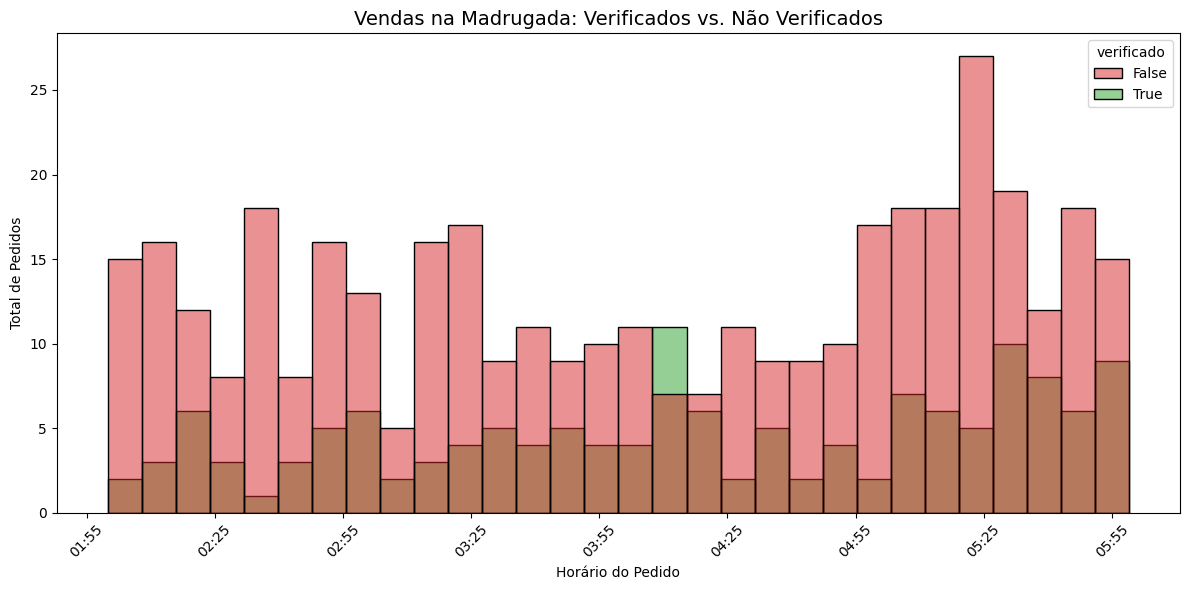

In [10]:
vendas_com_status = vendas_2_5_am.merge(df_vendedor[['vendedor_id', 'verificado']], on='vendedor_id', how='left')

plt.figure(figsize=(12, 6))

ax = sns.histplot(
    data=vendas_com_status, 
    x='_hora_pedido_dt', 
    hue='verificado', 
    palette={True: '#2ca02c', False: '#d62728'}, # Verde para Verificado, Vermelho para Não
    bins=30,
    multiple='layer' 
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))

plt.xticks(rotation=45)
plt.title('Vendas na Madrugada: Verificados vs. Não Verificados', fontsize=14)
plt.xlabel('Horário do Pedido')
plt.ylabel('Total de Pedidos')

plt.tight_layout()
plt.show()

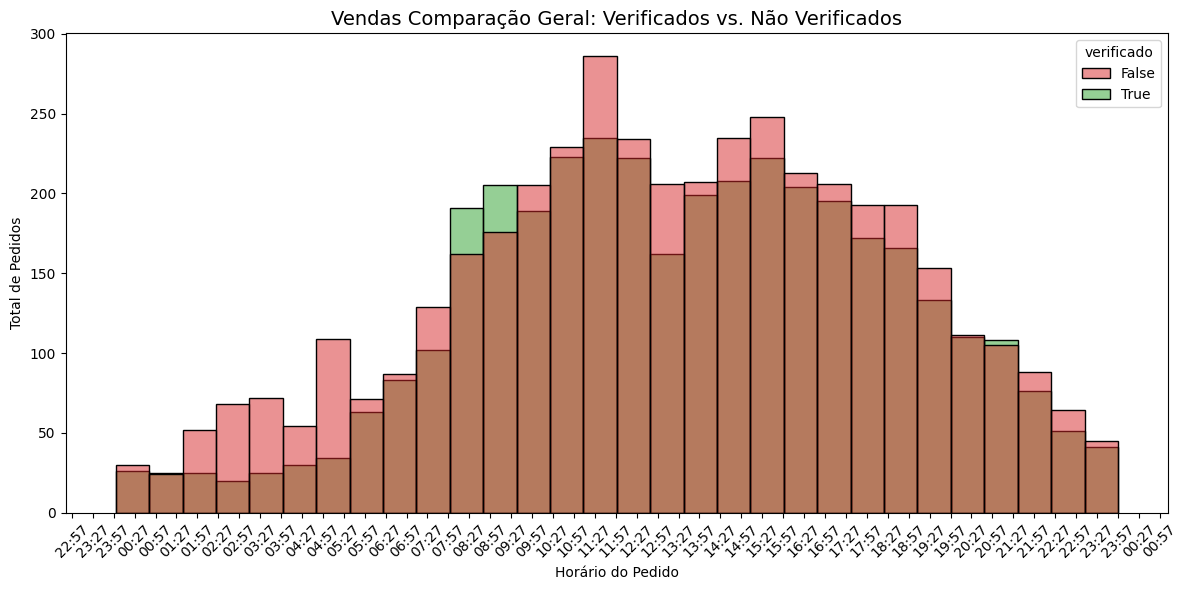

In [12]:
vendas_com_status_geral = df_vendas.merge(df_vendedor[['vendedor_id', 'verificado']], on='vendedor_id', how='left')

plt.figure(figsize=(12, 6))

ax = sns.histplot(
    data=vendas_com_status_geral, 
    x='_hora_pedido_dt', 
    hue='verificado', 
    palette={True: '#2ca02c', False: '#d62728'}, # Verde para Verificado, Vermelho para Não
    bins=30,
    multiple='layer' 
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))

plt.xticks(rotation=45)
plt.title('Vendas Comparação Geral: Verificados vs. Não Verificados', fontsize=14)
plt.xlabel('Horário do Pedido')
plt.ylabel('Total de Pedidos')

plt.tight_layout()
plt.show()

---
2. **Há avaliações falsas?** Identifique padrões: contas criadas há poucos dias que avaliam com nota 5, IPs repetidos, textos idênticos.

In [45]:
df_aval_sus['tempo_criacao_conta_dias'] = (df_aval_sus['_data_avaliacao_dt'] - df_aval_sus['_data_criacao_conta_dt']).dt.days
df_aval_sus_info = df_aval_sus.merge(df_vendedor, on='vendedor_id', how='left')

In [54]:
df_aval_sus_info['tempo_criacao_conta_dias'].describe()

count    3000.000000
mean      366.727000
std       208.722885
min         1.000000
25%       188.000000
50%       365.000000
75%       548.000000
max       730.000000
Name: tempo_criacao_conta_dias, dtype: float64

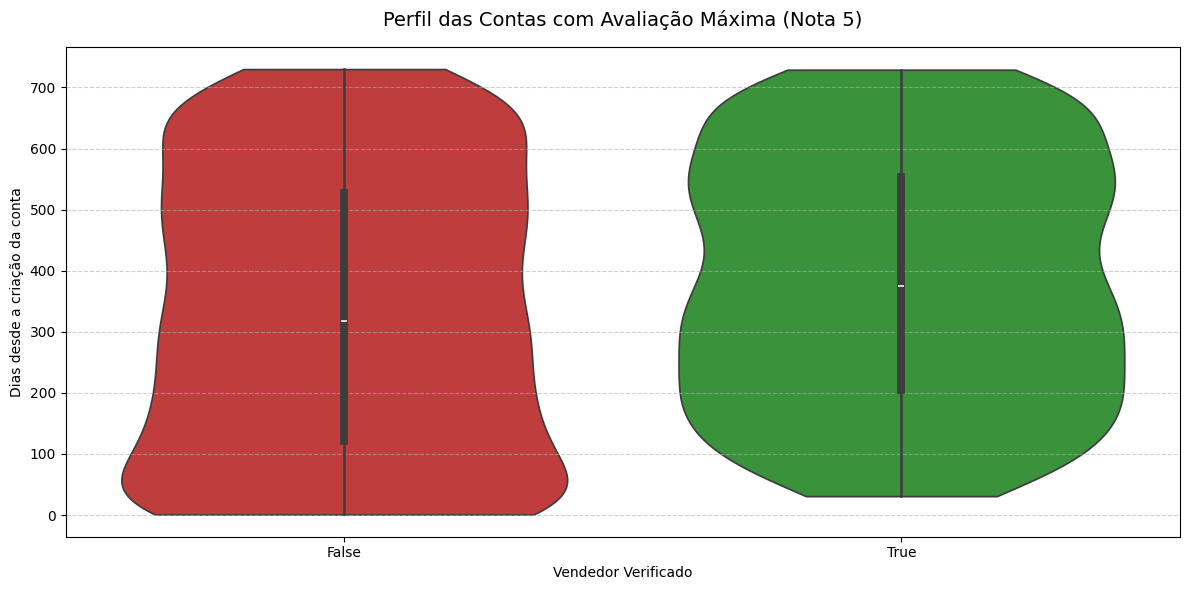

In [63]:
plt.figure(figsize=(12, 6))
df_nota_5 = df_aval_sus_info.query('nota == 5')

sns.violinplot(
    data=df_nota_5, 
    x='verificado',
    y='tempo_criacao_conta_dias', 
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}, 
    inner="box",
    cut=0,
    legend=False
)

# Estilização extra
plt.grid(axis='y', linestyle='--', alpha=0.6) # Ajuda a ler os dias exatos
plt.ylabel('Dias desde a criação da conta')
plt.xlabel('Vendedor Verificado')
plt.title('Perfil das Contas com Avaliação Máxima (Nota 5)', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

In [111]:
# Preparando os dados
df_fraude = df_aval_sus_info.query('nota == 5').groupby(
    ['vendedor_id', 'verificado', 'ip_origem']
).size().reset_index(name='contagem_por_ip')

df_fraude.sort_values('contagem_por_ip', ascending=False)

,vendedor_id,verificado,ip_origem,contagem_por_ip
418,VEND-0043,False,192.168.1.100,9
432,VEND-0045,False,192.168.1.100,8
439,VEND-0046,False,192.168.1.100,7
434,VEND-0045,False,192.168.1.105,7
441,VEND-0046,False,192.168.1.105,7
...,...,...,...,...
1104,VEND-0118,True,133.72.164.70,1
1105,VEND-0118,True,191.108.215.174,1
1106,VEND-0118,True,222.233.32.202,1
1107,VEND-0118,True,24.230.35.3,1


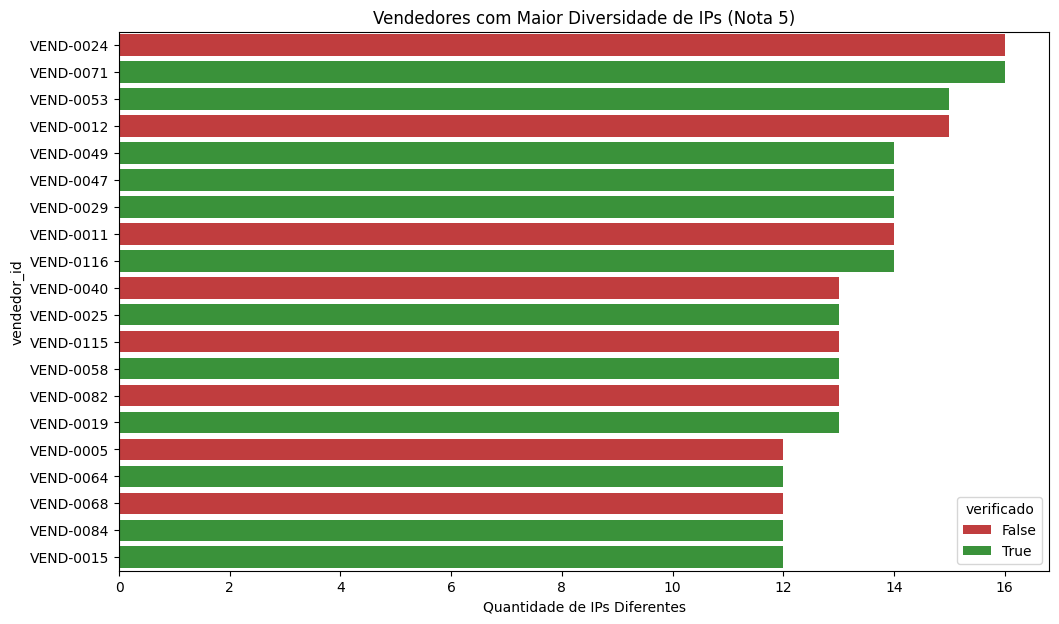

In [131]:
distribuicao_ips = df_aval_sus_info.query('nota == 5').groupby(
    ['vendedor_id', 'verificado']
)['ip_origem'].nunique().reset_index(name='qtd_ips_unicos')

top_distribuicao = distribuicao_ips.sort_values('qtd_ips_unicos', ascending=False).head(20)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_distribuicao,
    x='qtd_ips_unicos',
    y='vendedor_id',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}
)

plt.title('Vendedores com Maior Diversidade de IPs (Nota 5)')
plt.xlabel('Quantidade de IPs Diferentes')
plt.show()

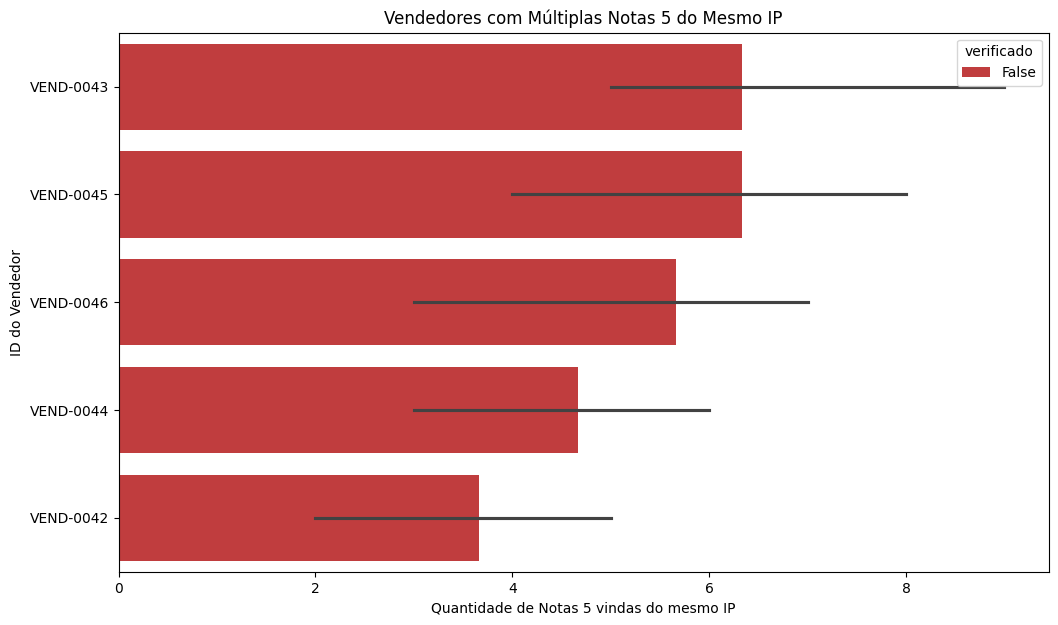

In [116]:
top_suspeitos = df_fraude.query('contagem_por_ip > 1').sort_values('contagem_por_ip', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_suspeitos,
    x='contagem_por_ip',
    y='vendedor_id', # Ou ip_origem, se preferir focar no IP
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
)

plt.title('Vendedores com Múltiplas Notas 5 do Mesmo IP')
plt.xlabel('Quantidade de Notas 5 vindas do mesmo IP')
plt.ylabel('ID do Vendedor')
plt.show()

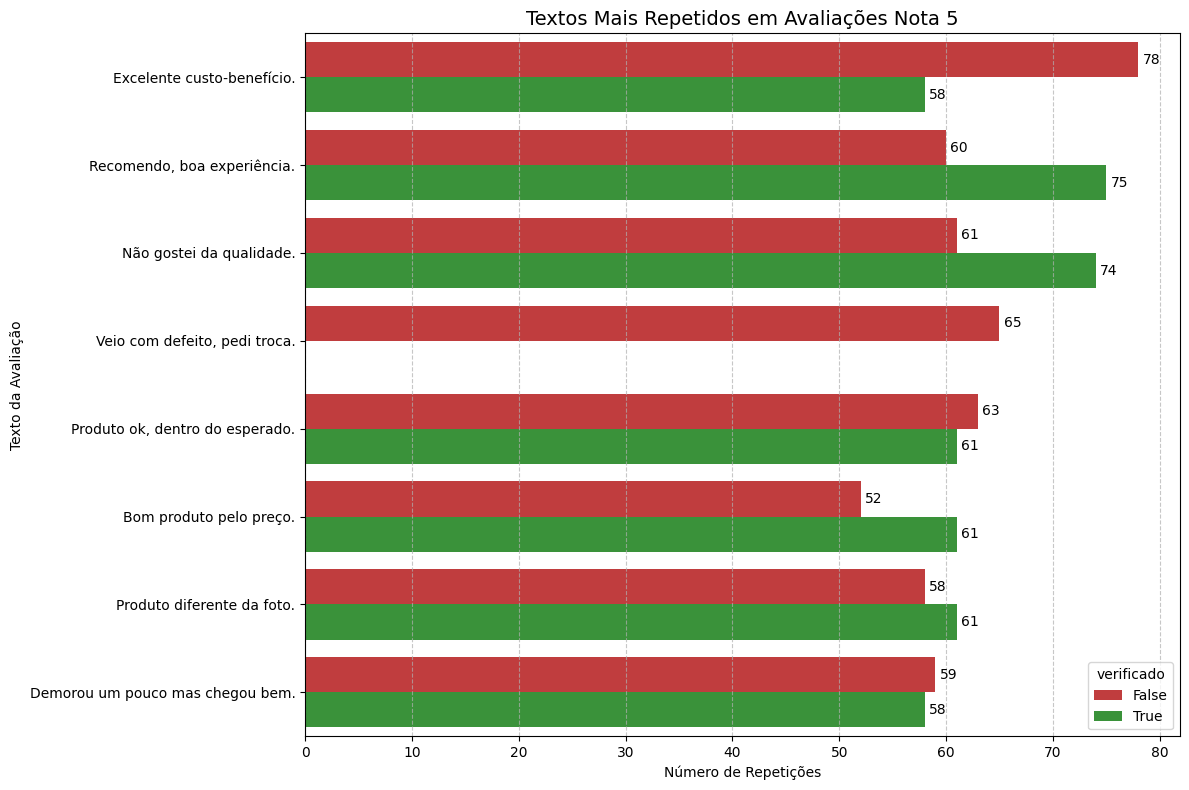

In [124]:
df_textos = df_aval_sus_info.query('nota == 5').groupby(
    ['texto_avaliacao', 'verificado']
).size().reset_index(name='contagem')

top_textos = df_textos.sort_values('contagem', ascending=False).head(15)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=top_textos,
    x='contagem',
    y='texto_avaliacao',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}
)


for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title('Textos Mais Repetidos em Avaliações Nota 5', fontsize=14)
plt.xlabel('Número de Repetições')
plt.ylabel('Texto da Avaliação')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

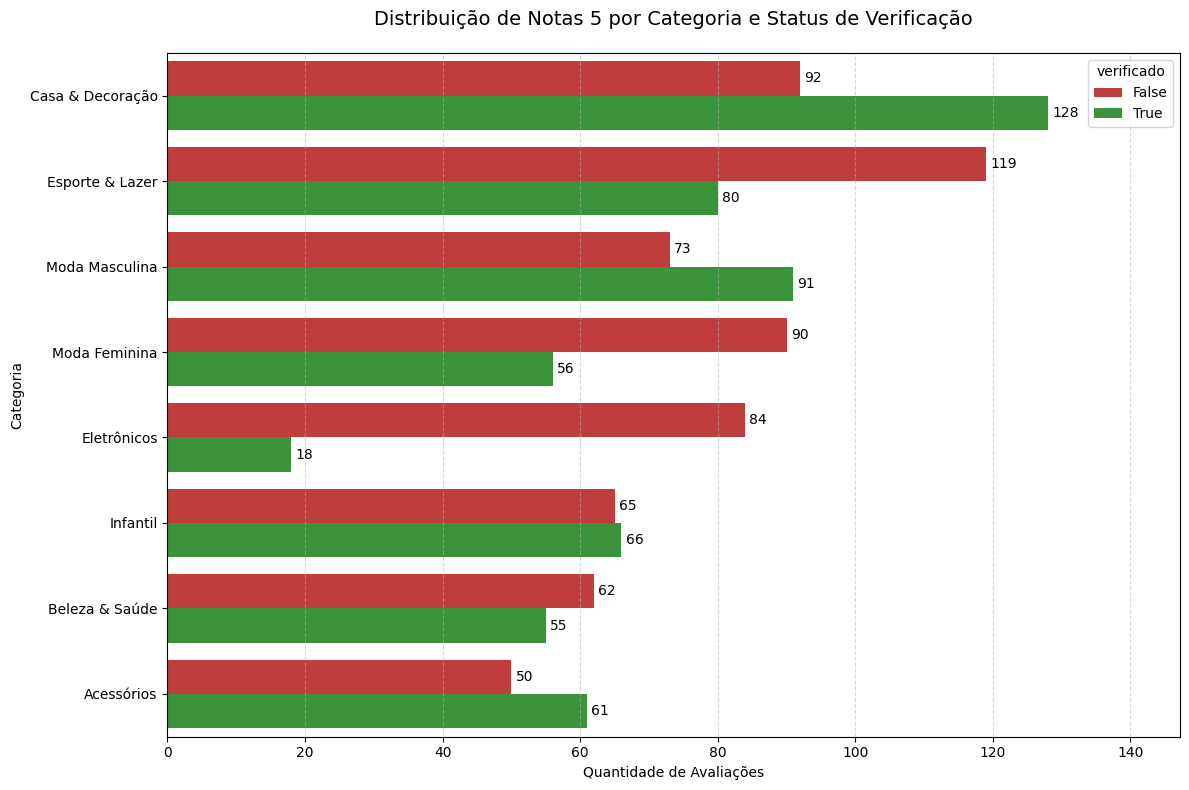

In [125]:
df_categorias = df_aval_sus_info.query('nota == 5').groupby(
    ['categoria_principal', 'verificado']
).size().reset_index(name='contagem')

df_categorias = df_categorias.sort_values('contagem', ascending=False)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=df_categorias,
    x='contagem',
    y='categoria_principal',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'} 
)

# Adicionando os valores nas barras
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title('Distribuição de Notas 5 por Categoria e Status de Verificação', fontsize=14, pad=20)
plt.xlabel('Quantidade de Avaliações')
plt.ylabel('Categoria')

# Ajustando o limite do eixo X para o texto não cortar
plt.xlim(0, df_categorias['contagem'].max() * 1.15)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
3. **Os vendedores suspeitos compartilham características em comum?** Cruze com o cadastro: data de cadastro próxima, mesma cidade, nomes similares, não verificados.

In [ ]:
df_sus

---
4. **Qual o impacto financeiro** das vendas dos vendedores suspeitos? Quanto representam do faturamento total?

---
5. **A taxa de cancelamento/devolução** dos vendedores suspeitos é diferente dos demais?

---
6. **Construa um "score de risco"** baseado nos indicadores encontrados. Quais critérios compõem esse score?

---
7. **Proponha regras automáticas** para detectar fraudes futuras baseadas nos padrões descobertos.

Regras

1. **Horário irrelevante até o momento**: ...